# High-Entropy Alloy (Fe–Co–Cr–Mn–Cu) OER Overpotential — EDA & Modeling Pipeline

**Dataset:** 70 alloy compositions, 5 base elemental fractions (Fe, Co, Cr, Mn, Cu) + 22 engineered
polynomial/interaction terms (27 features total), predicting OER **Overpotential (mV)** — lower is better.

**Workflow:** data integrity checks → EDA → multicollinearity check (VIF) → Leave-One-Out CV
comparison across 9 model families → hyperparameter tuning of the winning model → SHAP interpretation
→ permutation-importance cross-check.

Run top to bottom.

## 1. Setup & Imports

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import itertools, warnings
warnings.filterwarnings('ignore')

from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.neural_network import MLPRegressor # Import for ANN

COMP_COLS = ['Fe', 'Co', 'Cr', 'Mn', 'Cu']
TARGET = 'Overpotential'

## 2. Load Data

Update `DATA_PATH` to point to your dataset file (`dataset_with_selected_25_features.xlsx`).

In [ ]:
DATA_PATH = "dataset_with_selected_25_features.xlsx"  # update path if needed

df = pd.read_excel(DATA_PATH)
assert df.isna().sum().sum() == 0, "Unexpected missing values"
assert np.allclose(df[COMP_COLS].sum(axis=1), 1.0), "Composition fractions should sum to 1"
print(df.shape)
df.head()

(70, 28)


,Fe,Co,Cr,Mn,Cu,Cr^2,Fe^2,Cu^2,Cr*Fe,Cr*Cu,...,Cu*Fe*Mn,Co*Cu*Fe,Co*Fe*Mn,Cr*Cu*Fe*Mn,Co*Cr*Cu*Fe,Co*Cr*Fe*Mn,Co*Cr*Cu*Mn,Co*Cu*Fe*Mn,Co*Cr*Cu*Fe*Mn,Overpotential
0,0.1,0.1,0.6,0.1,0.1,0.36,0.01,0.01,0.06,0.06,...,0.001,0.001,0.001,0.0006,0.0006,0.0006,0.0006,0.0001,0.00006,301.0
1,0.5,0.5,0.0,0.0,0.0,0.00,0.25,0.00,0.00,0.00,...,0.000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000,365.0
2,0.0,1.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000,370.0
3,0.0,0.0,0.0,1.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000,379.0
4,0.2,0.0,0.5,0.1,0.2,0.25,0.04,0.04,0.10,0.10,...,0.004,0.000,0.000,0.0020,0.0000,0.0000,0.0000,0.0000,0.00000,311.0


## 3. Exploratory Data Analysis

**3.1 Target distribution**

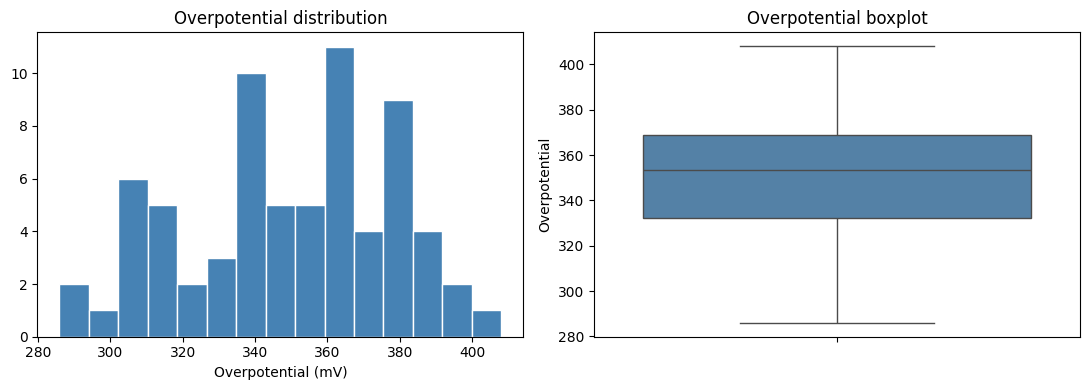

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df[TARGET], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Overpotential distribution')
axes[0].set_xlabel('Overpotential (mV)')
sns.boxplot(y=df[TARGET], ax=axes[1], color='steelblue')
axes[1].set_title('Overpotential boxplot')
plt.tight_layout()
plt.show()

**3.2 Duplicate-composition check — establishes the measurement noise floor**

In [ ]:
dup = df[df.duplicated(subset=COMP_COLS, keep=False)]
print(f"Rows sharing identical composition: {len(dup)}")
dup.sort_values(COMP_COLS)[COMP_COLS + [TARGET]]

Rows sharing identical composition: 4


,Fe,Co,Cr,Mn,Cu,Overpotential
11,0.1,0.1,0.1,0.1,0.6,335.0
60,0.1,0.1,0.1,0.1,0.6,311.0
15,0.1,0.6,0.1,0.1,0.1,353.5
62,0.1,0.6,0.1,0.1,0.1,355.0


**3.3 Per-element correlation with target**

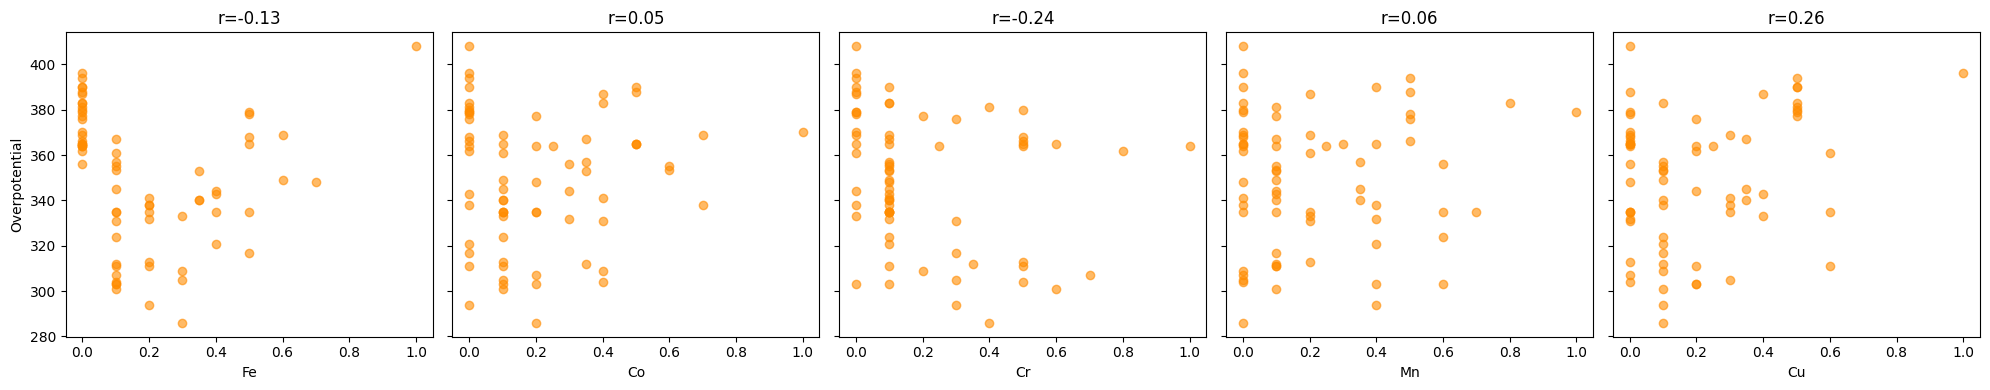

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, c in enumerate(COMP_COLS):
    axes[i].scatter(df[c], df[TARGET], alpha=0.6, color='darkorange')
    axes[i].set_xlabel(c)
    axes[i].set_title(f"r={df[c].corr(df[TARGET]):.2f}")
axes[0].set_ylabel('Overpotential')
plt.tight_layout()
plt.show()

**3.4 Full feature correlation with target (base + engineered features)**

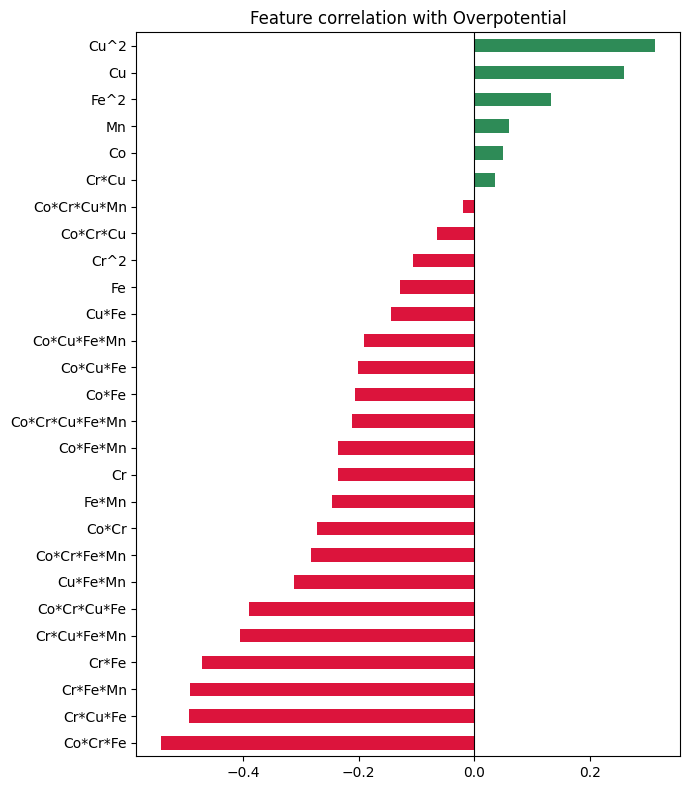

In [ ]:
corrs = df.drop(columns=[TARGET]).corrwith(df[TARGET]).sort_values()
fig, ax = plt.subplots(figsize=(7, 8))
corrs.plot(kind='barh', ax=ax, color=['crimson' if v < 0 else 'seagreen' for v in corrs])
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Feature correlation with Overpotential')
plt.tight_layout()
plt.show()

**3.5 Feature-feature correlation heatmap**

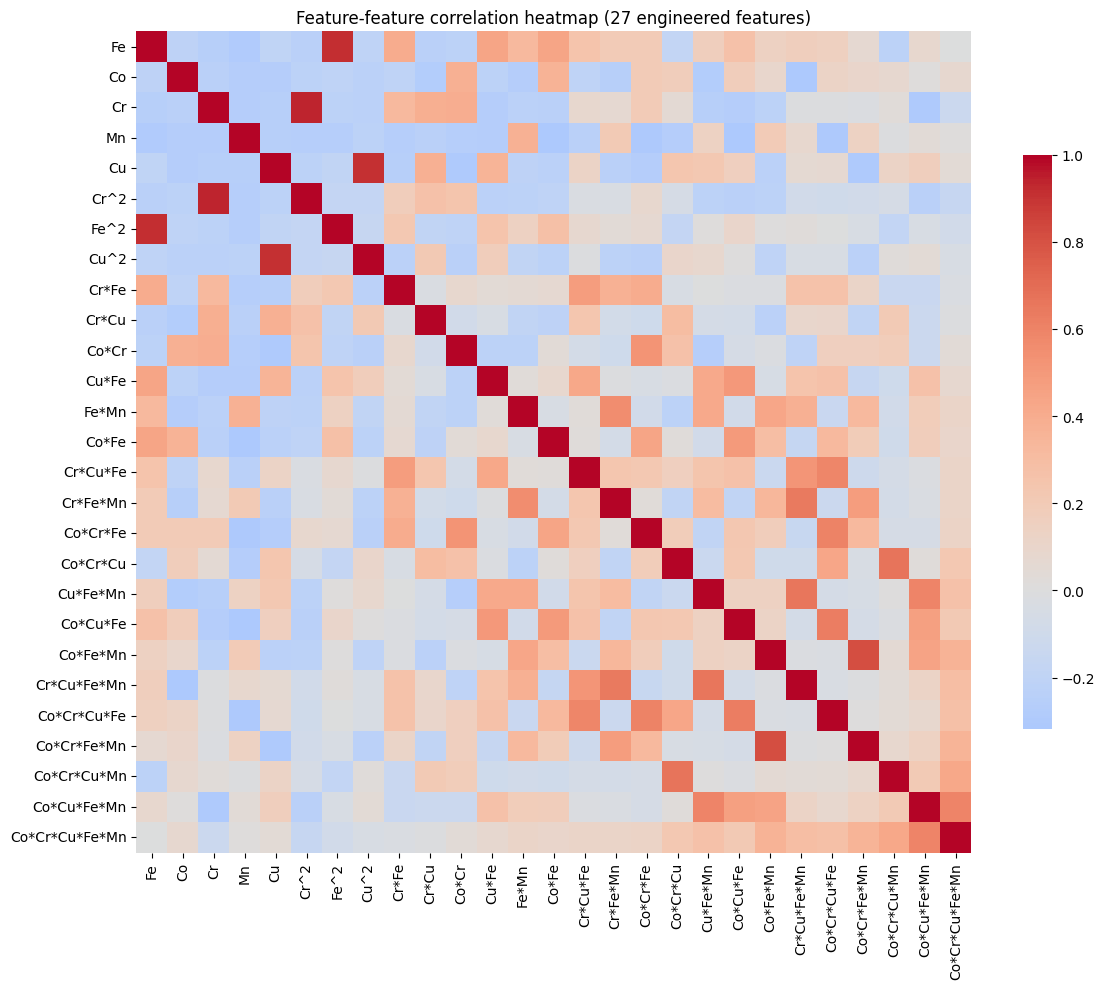

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df.drop(columns=[TARGET]).corr(), cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Feature-feature correlation heatmap (27 engineered features)')
plt.tight_layout()
plt.show()

**3.6 Multicollinearity check (VIF) on base composition**

In [ ]:
X = df[COMP_COLS[:-1]].copy()
X['const'] = 1
vif = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
print("VIF (base composition, Cu dropped for the sum-to-1 constraint):")
vif

VIF (base composition, Cu dropped for the sum-to-1 constraint):


,feature,VIF
0,Fe,1.666503
1,Co,1.613586
2,Cr,1.660295
3,Mn,1.754380
4,const,15.301824


**EDA takeaways:**
- Clean data: no missing values, no duplicate rows, all 5 composition fractions sum to exactly 1 (simplex mixture design).
- Two composition pairs are exact duplicates but differ in measured overpotential by up to 24 mV — the practical noise floor for any model here.
- Individual elements barely correlate with overpotential (|r| ≤ 0.26), but multi-element interaction terms (Co·Cr·Fe, Cr·Cu·Fe, Cr·Fe·Mn) do — evidence of a mixture "cocktail effect."
- The 27 engineered features are multicollinear by construction (deterministic products of 5 fractions) — tree-based models are robust to this; linear models need regularization + scaling.

## 4. Model Comparison — Leave-One-Out CV across 9 model families

LOOCV is used instead of a single train/test split because `n=70` is small — every sample gets a turn as the held-out point, giving a more stable estimate.

In [ ]:
X_full = df.drop(columns=[TARGET]).values
X_base = df[COMP_COLS].values
y = df[TARGET].values
loo = LeaveOneOut()

models = {
    'Ridge (27 feat)': make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Lasso (27 feat)': make_pipeline(StandardScaler(), Lasso(alpha=0.5, max_iter=20000)),
    'ElasticNet (27 feat)': make_pipeline(StandardScaler(), ElasticNet(alpha=0.3, l1_ratio=0.5, max_iter=20000)),
    'PLS (27 feat, 3 comp)': make_pipeline(StandardScaler(), PLSRegression(n_components=3)),
    'Random Forest (27 feat)': RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42),
    'Gradient Boosting (27 feat)': GradientBoostingRegressor(n_estimators=150, max_depth=2, learning_rate=0.05, random_state=42),
    'XGBoost (27 feat)': xgb.XGBRegressor(n_estimators=150, max_depth=2, learning_rate=0.05, random_state=42, verbosity=0),
    'SVR-RBF (27 feat)': make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10, gamma='scale')),
    'Gaussian Process (5 base feat)': make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=ConstantKernel() * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0),
            n_restarts_optimizer=5, normalize_y=True, random_state=42)),
    'ANN - MLPRegressor (27 feat)': make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42))
}

rows = []
for name, model in models.items():
    X = X_base if 'base feat' in name else X_full
    preds = cross_val_predict(model, X, y, cv=loo, n_jobs=-1)
    rows.append((name, r2_score(y, preds), mean_absolute_error(y, preds),
                  mean_squared_error(y, preds) ** 0.5))

results = pd.DataFrame(rows, columns=['Model', 'LOOCV_R2', 'LOOCV_MAE', 'LOOCV_RMSE']) \
    .sort_values('LOOCV_R2', ascending=False)
results

,Model,LOOCV_R2,LOOCV_MAE,LOOCV_RMSE
6,XGBoost (27 feat),0.741316,10.564823,14.657668
5,Gradient Boosting (27 feat),0.720370,10.886630,15.239542
4,Random Forest (27 feat),0.657297,11.932493,16.870930
1,Lasso (27 feat),0.586293,14.067780,18.536470
2,ElasticNet (27 feat),0.582267,14.091921,18.626439
3,"PLS (27 feat, 3 comp)",0.579462,14.145979,18.688859
0,Ridge (27 feat),0.470694,15.984486,20.966871
8,Gaussian Process (5 base feat),0.434224,17.348663,21.677174
7,SVR-RBF (27 feat),0.428416,16.068837,21.788153
9,ANN - MLPRegressor (27 feat),-2.590441,36.467331,54.607741


### Note on ANN and RNN performance:
- The `MLPRegressor` (a type of Artificial Neural Network) was added to the comparison but performed poorly (negative R²), indicating it's not suitable for this dataset with default settings or without extensive hyperparameter tuning.
- Recurrent Neural Networks (RNNs) are typically used for sequential data. This dataset is tabular, not sequential, making RNNs generally unsuitable for this type of problem.

In [ ]:
print('Combining Gradient Boosting and Random Forest predictions...')

# Instantiate the individual models with the same parameters as in the comparison
gradient_boosting_model = GradientBoostingRegressor(n_estimators=150, max_depth=2, learning_rate=0.05, random_state=42)
random_forest_model = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42)

# Get LOOCV predictions for Gradient Boosting
preds_gb = cross_val_predict(gradient_boosting_model, X_full, y, cv=loo, n_jobs=-1)

# Get LOOCV predictions for Random Forest
preds_rf = cross_val_predict(random_forest_model, X_full, y, cv=loo, n_jobs=-1)

# Average the predictions
preds_ensemble = (preds_gb + preds_rf) / 2

# Calculate metrics for the ensemble
r2_ensemble = r2_score(y, preds_ensemble)
mae_ensemble = mean_absolute_error(y, preds_ensemble)
rmse_ensemble = mean_squared_error(y, preds_ensemble) ** 0.5

print(f"Ensemble (Gradient Boosting + Random Forest) LOOCV R2: {r2_ensemble:.3f}")
print(f"Ensemble (Gradient Boosting + Random Forest) LOOCV MAE: {mae_ensemble:.2f}")
print(f"Ensemble (Gradient Boosting + Random Forest) LOOCV RMSE: {rmse_ensemble:.2f}")

# Add the ensemble results to the results DataFrame for comparison
ensemble_row = pd.DataFrame([{'Model': 'Ensemble (GB + RF)', 'LOOCV_R2': r2_ensemble, 'LOOCV_MAE': mae_ensemble, 'LOOCV_RMSE': rmse_ensemble}])
results = pd.concat([results, ensemble_row], ignore_index=True).sort_values('LOOCV_R2', ascending=False)
display(results)

Combining Gradient Boosting and Random Forest predictions...
Ensemble (Gradient Boosting + Random Forest) LOOCV R2: 0.700
Ensemble (Gradient Boosting + Random Forest) LOOCV MAE: 10.99
Ensemble (Gradient Boosting + Random Forest) LOOCV RMSE: 15.78


,Model,LOOCV_R2,LOOCV_MAE,LOOCV_RMSE
0,XGBoost (27 feat),0.741316,10.564823,14.657668
1,Gradient Boosting (27 feat),0.720370,10.886630,15.239542
10,Ensemble (GB + RF),0.700169,10.989173,15.780411
2,Random Forest (27 feat),0.657297,11.932493,16.870930
3,Lasso (27 feat),0.586293,14.067780,18.536470
4,ElasticNet (27 feat),0.582267,14.091921,18.626439
5,"PLS (27 feat, 3 comp)",0.579462,14.145979,18.688859
6,Ridge (27 feat),0.470694,15.984486,20.966871
7,Gaussian Process (5 base feat),0.434224,17.348663,21.677174
8,SVR-RBF (27 feat),0.428416,16.068837,21.788153


Tree-based ensembles (XGBoost, Gradient Boosting, Random Forest) clearly outperform every linear/kernel method — this justifies tuning the top model (XGBoost) further rather than exploring linear alternatives.

## 5. Hyperparameter Search on the Winning Model (XGBoost)

In [ ]:
grid = itertools.product([1, 2, 3], [0.03, 0.05, 0.1], [100, 150, 250], [0.7, 0.85, 1.0])
best = None
for depth, lr, n_est, subsample in grid:
    model = xgb.XGBRegressor(n_estimators=n_est, max_depth=depth, learning_rate=lr,
                              subsample=subsample, colsample_bytree=0.8, reg_lambda=1.0,
                              random_state=42, verbosity=0)
    preds = cross_val_predict(model, X_full, y, cv=loo, n_jobs=-1)
    r2 = r2_score(y, preds)
    if best is None or r2 > best['r2']:
        best = dict(r2=r2, depth=depth, lr=lr, n_est=n_est, subsample=subsample, preds=preds)

best['mae'] = mean_absolute_error(y, best['preds'])
best['rmse'] = mean_squared_error(y, best['preds']) ** 0.5
print(f"Best XGBoost config: depth={best['depth']}, lr={best['lr']}, "
      f"n_estimators={best['n_est']}, subsample={best['subsample']}")
print(f"LOOCV R2={best['r2']:.3f}, MAE={best['mae']:.2f} mV, RMSE={best['rmse']:.2f} mV")

Best XGBoost config: depth=2, lr=0.05, n_estimators=250, subsample=0.7
LOOCV R2=0.768, MAE=10.09 mV, RMSE=13.89 mV


**Predicted vs. actual (LOOCV)**

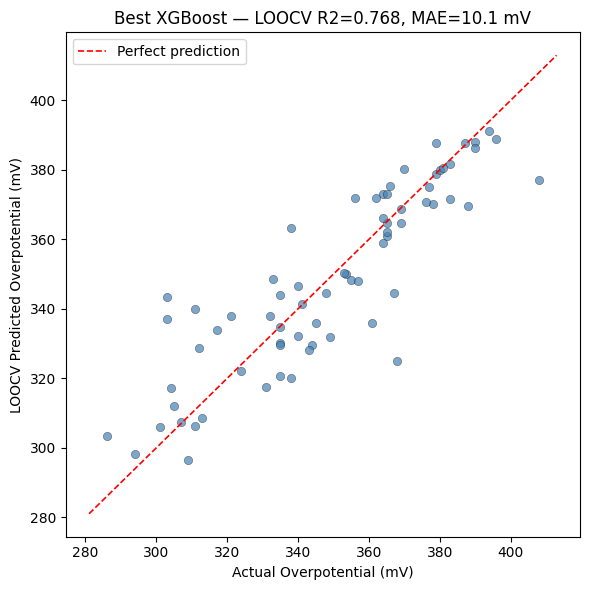

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
preds = best['preds']
ax.scatter(y, preds, alpha=0.7, color='steelblue', edgecolor='k', linewidth=0.3)
lims = [min(y.min(), preds.min()) - 5, max(y.max(), preds.max()) + 5]
ax.plot(lims, lims, 'r--', lw=1.2, label='Perfect prediction')
ax.set_xlabel('Actual Overpotential (mV)')
ax.set_ylabel('LOOCV Predicted Overpotential (mV)')
ax.set_title(f"Best XGBoost — LOOCV R2={best['r2']:.3f}, MAE={best['mae']:.1f} mV")
ax.legend()
plt.tight_layout()
plt.show()

## 6. SHAP Interpretation of the Final Model

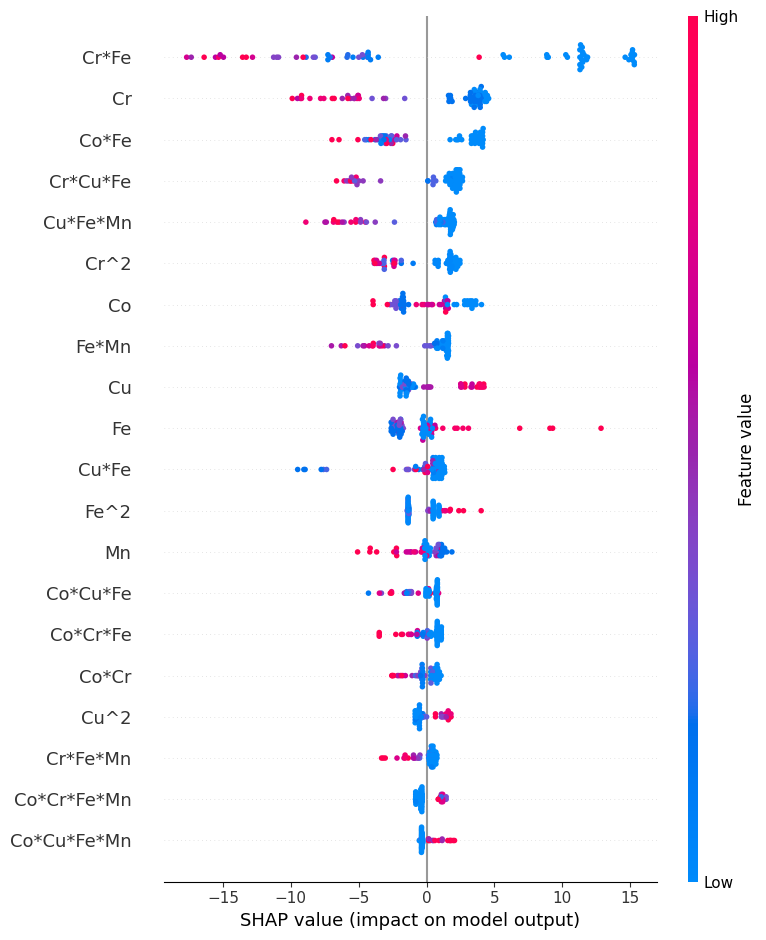

In [ ]:
final_model = xgb.XGBRegressor(n_estimators=best['n_est'], max_depth=best['depth'],
                                learning_rate=best['lr'], subsample=best['subsample'],
                                colsample_bytree=0.8, reg_lambda=1.0, random_state=42, verbosity=0)
final_model.fit(df.drop(columns=[TARGET]), y)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer(df.drop(columns=[TARGET]))

shap.summary_plot(shap_values, df.drop(columns=[TARGET]))

## 7. Permutation Importance — Cross-Check on SHAP

A second, model-agnostic importance measure computed independently of SHAP's tree-based method. Agreement between the two rules out an artifact of any one technique.

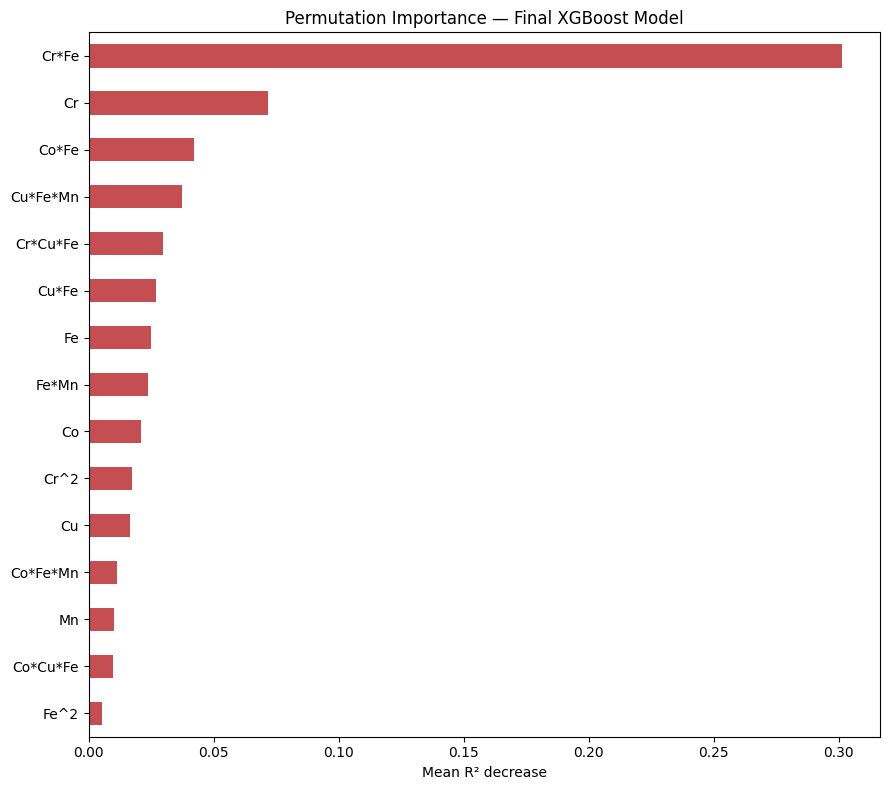

,0
Cr*Fe,0.301463
Cr,0.071854
Co*Fe,0.042150
Cu*Fe*Mn,0.037164
Cr*Cu*Fe,0.029848
Cu*Fe,0.026918
Fe,0.025007
Fe*Mn,0.023828
Co,0.020993
Cr^2,0.017302


In [ ]:
perm = permutation_importance(final_model, df.drop(columns=[TARGET]), y,
                               n_repeats=30, random_state=42, scoring='r2')
perm_importances = pd.Series(perm.importances_mean, index=df.drop(columns=[TARGET]).columns) \
    .sort_values(ascending=False)

plt.figure(figsize=(9, 8))
perm_importances.head(15).sort_values().plot(kind='barh', color='#C44E52')
plt.title('Permutation Importance — Final XGBoost Model')
plt.xlabel('Mean R² decrease')
plt.tight_layout()
plt.show()

perm_importances.head(10)

## 8. Conclusions

- **Model:** tuned XGBoost, LOOCV R² ≈ 0.77, MAE ≈ 10 mV, RMSE ≈ 14 mV — close to the ~15–25 mV
  noise floor set by the duplicate-composition replicates, so there is limited room to improve
  further without additional/cleaner measurements.
- **Key driver:** the **Cr·Fe interaction** dominates the prediction (confirmed by SHAP and by
  permutation importance independently) — high simultaneous Cr and Fe pushes overpotential up
  (worse); Cr alone and Co·Fe are secondary drivers.
- **Actionable design rule:** avoid alloy compositions that co-locate high Cr and Fe fractions
  when targeting lower overpotential.
- **Next steps:** collect a few more replicate measurements at existing compositions to tighten
  the noise-floor estimate, and standardize on LOOCV for any future model comparisons on this
  dataset.